In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)


In [2]:
# Load processed files
X_train = pd.read_csv('data/X_train.csv')
X_test = pd.read_csv('data/X_test.csv')
y_train = pd.read_csv('data/y_train.csv').values.ravel()
y_test = pd.read_csv('data/y_test.csv').values.ravel()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (7776, 15)
X_test shape: (1022, 15)
y_train shape: (7776,)
y_test shape: (1022,)


In [18]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}")
    print('='*60)
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"Accuracy : {results[name]['accuracy']:.4f}")
    print(f"Precision: {results[name]['precision']:.4f}")
    print(f"Recall   : {results[name]['recall']:.4f} ")
    print(f"F1 Score : {results[name]['f1']:.4f}")
    print(f"ROC-AUC  : {results[name]['roc_auc']:.4f}")


Training Logistic Regression
Accuracy : 0.7368
Precision: 0.1338
Recall   : 0.8000 
F1 Score : 0.2292
ROC-AUC  : 0.8406

Training Random Forest
Accuracy : 0.9188
Precision: 0.1633
Recall   : 0.1600 
F1 Score : 0.1616
ROC-AUC  : 0.7509

Training Gradient Boosting
Accuracy : 0.8532
Precision: 0.1479
Recall   : 0.4200 
F1 Score : 0.2188
ROC-AUC  : 0.7883


In [19]:
comparison = pd.DataFrame({
    name: {
        'Accuracy': res['accuracy'],
        'Precision': res['precision'],
        'Recall': res['recall'],
        'F1 Score': res['f1'],
        'ROC-AUC': res['roc_auc']
    } for name, res in results.items()
}).T

print(" Model Comparison")
comparison.round(4)

 Model Comparison


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.7368,0.1338,0.80,0.2292,0.8406
Random Forest,0.9188,0.1633,0.16,0.1616,0.7509
Gradient Boosting,0.8532,0.1479,0.42,0.2188,0.7883


<Figure size 1200x600 with 0 Axes>

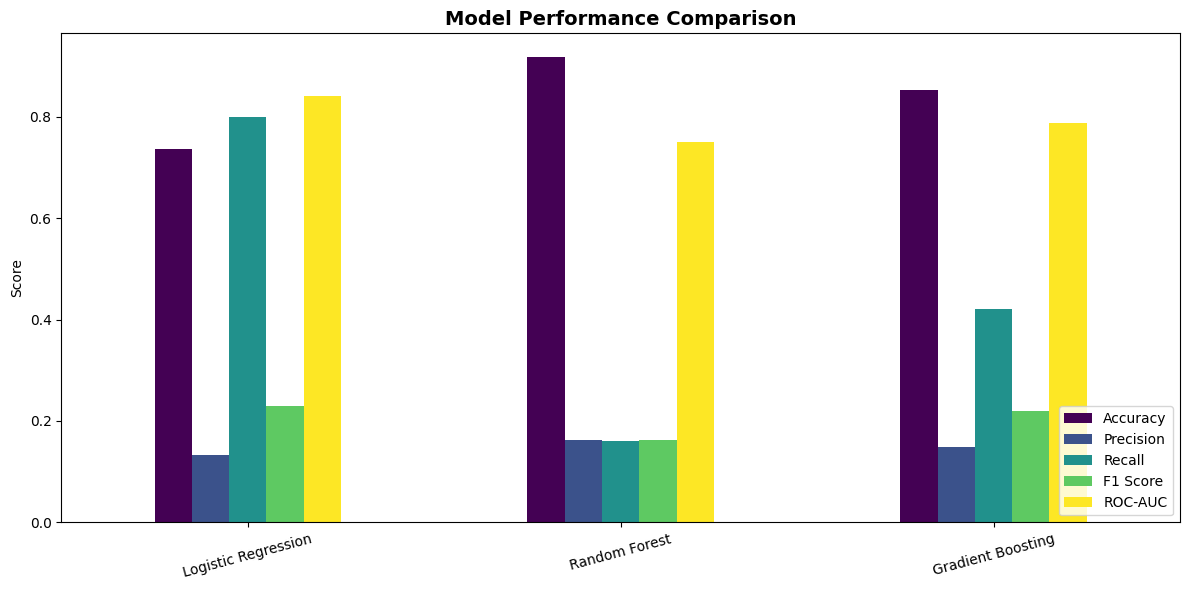

In [5]:
plt.figure(figsize=(12, 6))
comparison.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('reports/figures/06_model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

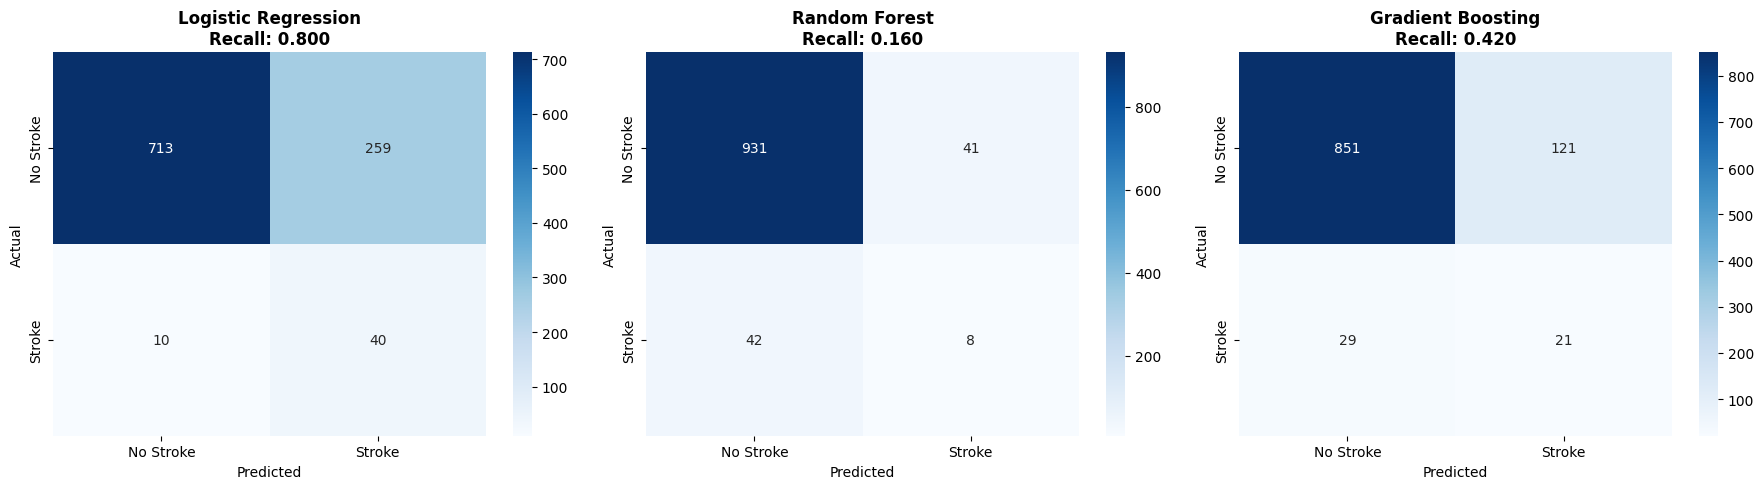

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Stroke', 'Stroke'],
                yticklabels=['No Stroke', 'Stroke'])
    axes[idx].set_title(f'{name}\nRecall: {res["recall"]:.3f}', fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('reports/figures/07_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

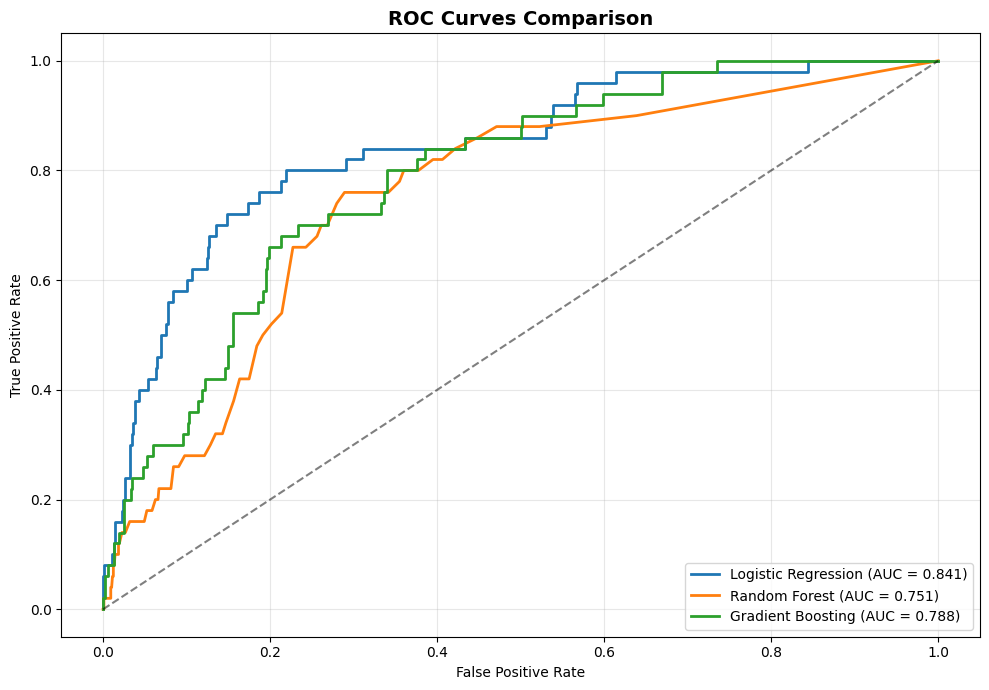

In [7]:

plt.figure(figsize=(10, 7))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_pred_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('reports/figures/08_roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

In [20]:
best_model_name = max(results, key=lambda x: results[x]['recall'])
print(f" Best baseline model based on Recall: {best_model_name}")
print(f"Recall score: {results[best_model_name]['recall']:.4f}")

 Best baseline model based on Recall: Logistic Regression
Recall score: 0.8000


In [22]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

print(" Running GridSearchCV...")
grid_search.fit(X_train, y_train)

print(" Best parameters found:")
print(grid_search.best_params_)
print(f"Best CV Recall: {grid_search.best_score_:.4f}")

 Running GridSearchCV...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
 Best parameters found:
{'learning_rate': 0.05, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Recall: 0.9599


In [23]:
best_model = grid_search.best_estimator_

y_pred_final = best_model.predict(X_test)
y_pred_proba_final = best_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print(" FINAL MODEL PERFORMANCE")
print("=" * 60)
print(f"Accuracy : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_final, zero_division=0):.4f} ⭐")
print(f"F1 Score : {f1_score(y_test, y_pred_final, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_proba_final):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_final, target_names=['No Stroke', 'Stroke'], zero_division=0))

 FINAL MODEL PERFORMANCE
Accuracy : 0.8591
Precision: 0.1643
Recall   : 0.4600 ⭐
F1 Score : 0.2421
ROC-AUC  : 0.7982

Classification Report:

              precision    recall  f1-score   support

   No Stroke       0.97      0.88      0.92       972
      Stroke       0.16      0.46      0.24        50

    accuracy                           0.86      1022
   macro avg       0.57      0.67      0.58      1022
weighted avg       0.93      0.86      0.89      1022



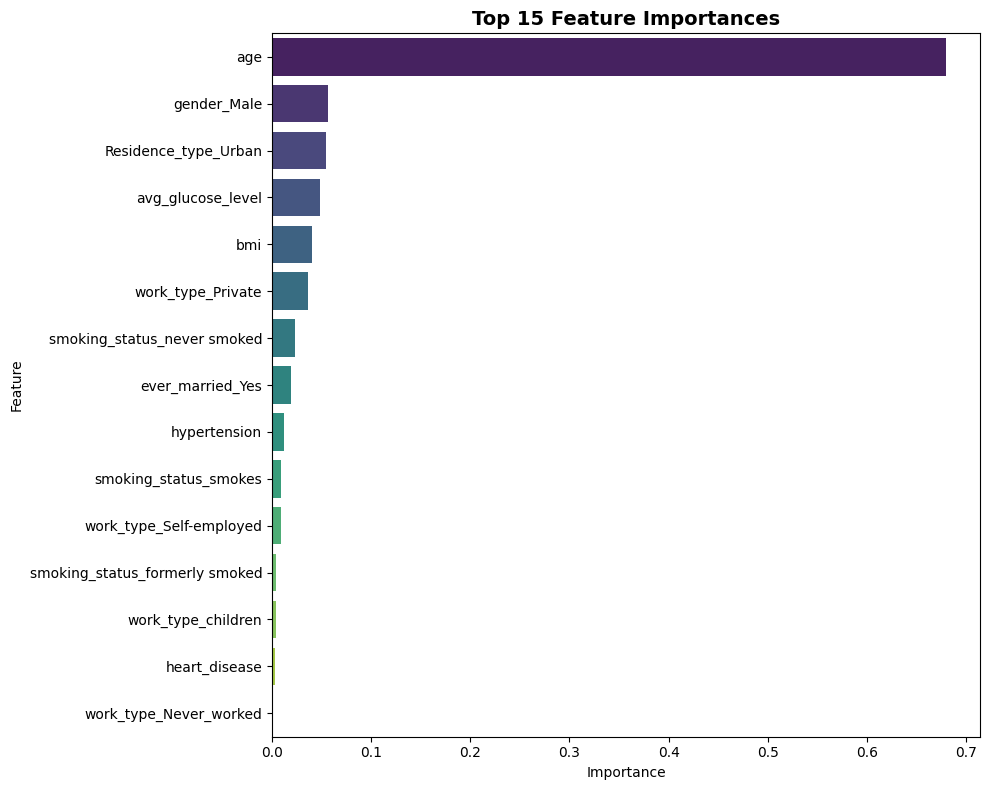

,feature,importance
0,age,0.680088
5,gender_Male,0.056633
11,Residence_type_Urban,0.054620
3,avg_glucose_level,0.048216
4,bmi,0.040300
8,work_type_Private,0.036360
13,smoking_status_never smoked,0.022909
6,ever_married_Yes,0.019494
1,hypertension,0.011683
14,smoking_status_smokes,0.009480


In [11]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('reports/figures/09_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

feature_importance.head(15)

In [24]:
joblib.dump(best_model, 'models/stroke_model.pkl')

print(" Final model saved successfully")
print("Saved file: models/stroke_model.pkl")

 Final model saved successfully
Saved file: models/stroke_model.pkl


In [25]:
print("=" * 70)
print(" MODELING COMPLETE")
print("=" * 70)

print(f"""
Final Model: Gradient Boosting (Tuned)

Key Metrics:
- Accuracy : {accuracy_score(y_test, y_pred_final):.4f}
- Precision: {precision_score(y_test, y_pred_final, zero_division=0):.4f}
- Recall   : {recall_score(y_test, y_pred_final, zero_division=0):.4f}
- F1 Score : {f1_score(y_test, y_pred_final, zero_division=0):.4f}
- ROC-AUC  : {roc_auc_score(y_test, y_pred_proba_final):.4f}



""")

 MODELING COMPLETE

Final Model: Gradient Boosting (Tuned)

Key Metrics:
- Accuracy : 0.8591
- Precision: 0.1643
- Recall   : 0.4600
- F1 Score : 0.2421
- ROC-AUC  : 0.7982




